In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
P = np.array([
    [0.332275, 0.154930, 0.224743, 0.288052],
    [0.343810, 0.233673, 0.044756, 0.377761],
    [0.280076, 0.192421, 0.228673, 0.298830],
    [0.228771, 0.171491, 0.226221, 0.373517]
], dtype=float)

alphabet = np.array(['A', 'C', 'G', 'T'])
idx = {b: i for i, b in enumerate(alphabet)}

In [3]:
# 1. Генератор последовательности
def generate_sequence(P, length, start_state):
    rng = np.random.default_rng()
    seq = [start_state]
    current = start_state

    for _ in range(length - 1):
        i = idx[current]
        next_state = rng.choice(alphabet, p=P[i])
        seq.append(next_state)
        current = next_state

    return ''.join(seq)

In [4]:
# 2. Подсчет матрицы переходов для одной последовательности
def transition_counts_from_seq(seq):
    counts = np.zeros((4, 4), dtype=int)
    for i in range(len(seq) - 1):
        a, b = seq[i], seq[i + 1]
        counts[idx[a], idx[b]] += 1
    return counts

def counts_to_probs(counts):
    row_sums = counts.sum(axis=1, keepdims=True)
    probs = np.divide(counts, row_sums, where=(row_sums != 0))
    probs[row_sums.flatten() == 0] = 0
    return probs


In [5]:
# 3. Генерация 10 последовательностей длиной 1000
sequences = []
all_counts = np.zeros((4, 4), dtype=int)

for n in range(10):
    seq = generate_sequence(P, length=1000, start_state='A')
    sequences.append(seq)
    all_counts += transition_counts_from_seq(seq)


In [6]:
# 4. Эмпирическая матрица переходов по всем 10 последовательностям
P_emp = counts_to_probs(all_counts)

print("Original matrix P:")
print(P)

print("\nEmpirical matrix from generated sequences:")
print(P_emp)

print("\nAbsolute difference |P_emp - P|:")
print(np.abs(P_emp - P))

print("\nMean absolute difference:", np.mean(np.abs(P_emp - P)))


Original matrix P:
[[0.332275 0.15493  0.224743 0.288052]
 [0.34381  0.233673 0.044756 0.377761]
 [0.280076 0.192421 0.228673 0.29883 ]
 [0.228771 0.171491 0.226221 0.373517]]

Empirical matrix from generated sequences:
[[0.32589444 0.14913213 0.23308537 0.29188806]
 [0.33503982 0.24288965 0.03640501 0.38566553]
 [0.27202869 0.17469262 0.22284836 0.33043033]
 [0.22505062 0.16459358 0.23025745 0.38009835]]

Absolute difference |P_emp - P|:
[[0.00638056 0.00579787 0.00834237 0.00383606]
 [0.00877018 0.00921665 0.00835099 0.00790453]
 [0.00804731 0.01772838 0.00582464 0.03160033]
 [0.00372038 0.00689742 0.00403645 0.00658135]]

Mean absolute difference: 0.008939717068829393


In [ ]:
# 5. Тепловые карты
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(P, cmap='viridis', vmin=0, vmax=max(P.max(), P_emp.max()))
axes[0].set_title('Original transition matrix P')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(alphabet)
axes[0].set_yticklabels(alphabet)

for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{P[i, j]:.3f}", ha='center', va='center', color='white')

im2 = axes[1].imshow(P_emp, cmap='viridis', vmin=0, vmax=max(P.max(), P_emp.max()))
axes[1].set_title('Empirical transition matrix')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(alphabet)
axes[1].set_yticklabels(alphabet)

for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{P_emp[i, j]:.3f}", ha='center', va='center', color='white')

fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.85)
plt.tight_layout()
plt.show()


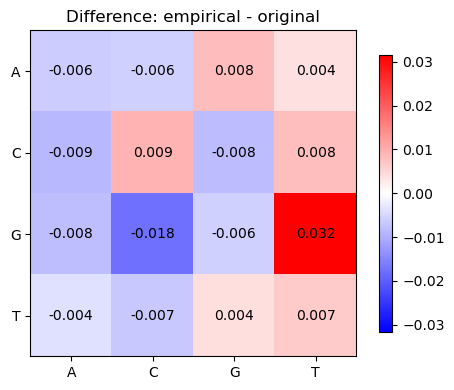

In [7]:
# 6. Дополнительно: тепловая карта разности
plt.figure(figsize=(5, 4))
diff = P_emp - P
im = plt.imshow(diff, cmap='bwr', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
plt.title('Difference: empirical - original')
plt.xticks(range(4), alphabet)
plt.yticks(range(4), alphabet)
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{diff[i, j]:.3f}", ha='center', va='center', color='black')
plt.colorbar(im, shrink=0.85)
plt.tight_layout()
plt.show()
